# Accessing Tools in Neurodesk

**Author**: Michèle Masson-Trottier

**Date**: 2026-03-10

**License:**
<div style="margin-top: 10px;">
    <a href="https://creativecommons.org/licenses/by/4.0/" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> CC-BY-4.0 License
    </a>
</div>

**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

### Citation and Resources

#### Tools included in this workflow

- **Neurodesk** — Renton, A.I., Dao, T.T., Johnstone, T. et al. Neurodesk: an accessible, flexible and portable data analysis environment for reproducible neuroimaging. *Nat Methods* 21, 804–808 (2024). [doi:10.1038/s41592-024-02237-2](https://doi.org/10.1038/s41592-024-02237-2)
- **Lmod** — McLay, R., Schulz, K.W., Barth, W.L., Minyard, T. Best Practices for the Deployment and Management of Production HPC Clusters. *SC11*, (2011). [https://lmod.readthedocs.io](https://lmod.readthedocs.io)
- **FSL** — Jenkinson, M., Beckmann, C.F., Behrens, T.E.J., Woolrich, M.W., Smith, S.M. FSL. *NeuroImage* 62, 782-790 (2012). [doi:10.1016/j.neuroimage.2011.09.015](https://doi.org/10.1016/j.neuroimage.2011.09.015)
- **FreeSurfer** — Fischl, B. FreeSurfer. *NeuroImage* 62, 774-781 (2012). [doi:10.1016/j.neuroimage.2012.01.021](https://doi.org/10.1016/j.neuroimage.2012.01.021)
- **ANTs** — Avants, B.B., Tustison, N.J., Song, G., et al. A reproducible evaluation of ANTs similarity metric performance in brain image registration. *NeuroImage* 54, 2033-2044 (2011). [doi:10.1016/j.neuroimage.2010.09.025](https://doi.org/10.1016/j.neuroimage.2010.09.025)

#### Dataset

- **OpenNeuro ds000102** — Kelly, A.M.C. et al. (2008). Competition between functional brain networks mediates behavioral variability. *NeuroImage* 39, 527-537. [doi:10.1016/j.neuroimage.2007.08.008](https://doi.org/10.1016/j.neuroimage.2007.08.008). Dataset available at [OpenNeuro](https://openneuro.org/datasets/ds000102).

#### Educational resources

- [Neurodesk Documentation](https://neurodesk.org)
- [NeurodeskEDU](https://neurodesk.org/edu/intro.html)
- [Lmod User Guide](https://lmod.readthedocs.io/en/latest/010_user.html)

### Statement of Need

Neurodesk provides access to a large collection of neuroimaging tools through containerised applications. New users often ask: *how do I actually run my tools?* The answer depends on which interface you're using.

This tutorial is for **anyone getting started with Neurodesk** — from first-time users to experienced researchers exploring a different interface. It covers the **four main ways** to access tools (Jupyter Terminal, Jupyter Notebook, Neurodesktop Terminal, and the Neurodesktop Application Menu), and demonstrates that all methods share the same underlying module system by loading a **different tool** in each section — FSL, FreeSurfer, and ANTs — then confirming they are all available together at the end.

### Learning Objectives

After completing this tutorial, you will be able to:

- [ ] Use `ml` commands to discover, load, and manage neuroimaging tools in a terminal
- [ ] Load tools programmatically inside a Jupyter notebook using `await module.load()`
- [ ] Launch tools from the Neurodesktop terminal and application menu
- [ ] Choose the appropriate access method for different tasks
- [ ] Combine tools loaded through different methods in a single session

## Table of Contents

[1. Jupyter Terminal — Loading FSL](#1.-Jupyter-Terminal-—-Loading-FSL)  
[2. Jupyter Notebook — Loading FreeSurfer](#2.-Jupyter-Notebook-—-Loading-FreeSurfer)  
[3. Neurodesktop Terminal — Loading ANTs](#3.-Neurodesktop-Terminal-—-Loading-ANTs)  
[4. Neurodesktop Application Menu](#4.-Neurodesktop-Application-Menu)  
[5. Putting It All Together](#5.-Putting-It-All-Together)  
[6. Comparison and Quick Reference](#6.-Comparison-and-Quick-Reference)

## Load software tools and install dependencies

In [1]:
%%capture
# Install packages not included in the Neurodesk base image
!pip install nibabel matplotlib

## 1. Jupyter Terminal — Loading FSL

The Jupyter Terminal gives you a full shell session inside the Neurodesk environment. This is the most direct way to interact with tools, and it works identically to using a terminal on an HPC system with environment modules.

![The JupyterLab interface in Neurodesk](/static/tutorials/about_neurodesk/jupyterlab_interface.png)
*The JupyterLab interface in Neurodesk — this is where you'll find the Terminal, Notebook, sidebar module panel, and file browser.*

In this section, we'll use it to load **FSL**.

### Launching a terminal

From JupyterLab, you can open a terminal in two ways:

- **Launcher tab** — click **Terminal** under "Other"
- **Menu** — File > New > Terminal

![JupyterLab Launcher tab with Terminal tile highlighted](/static/tutorials/about_neurodesk/launcher_terminal.png)
*The JupyterLab Launcher showing the Terminal option under "Neurodesk".*

### Loading tools from the sidebar

The JupyterLab sidebar includes a **Neurodesk module panel** (provided by the [`jupyter-lmod`](https://github.com/cmd-ntrf/jupyter-lmod) extension) that lists all available software containers. You can browse or search by name, and **click the "Load" button** next to any tool to activate it — no terminal commands needed. Here in the example below, Connectome Workbench 2.1.0 is loaded from the sidebar, making its executables available in a new terminal.

![Neurodesk sidebar showing tool categories and available software](/static/tutorials/about_neurodesk/sidebar_launcher.png)
*The Neurodesk module panel in the JupyterLab sidebar. Click "Load" next to a tool to activate it.*

Loading a tool from the sidebar sets the environment variables in the **JupyterLab server process**. This means:

- **Notebook cells** — tools loaded from the sidebar are immediately available via `!` shell escapes and `subprocess` calls in a Notebook
- **New terminals** — any terminal opened *after* loading from the sidebar will inherit the loaded modules
- **Already-open terminals** — terminals that were opened *before* you clicked "Load" in the sidebar will **not** see the new module

:::{warning}
**Important gotcha:** If you load a tool from the sidebar and want to use it in a terminal, you must open a **new** terminal after loading. Terminals that were already open will not pick up the change — their environment was set when they launched. If you prefer to use an existing terminal, run `ml <tool>` directly in that terminal instead.
:::

### Loading FSL with `ml`

Once you have a terminal open, you use the `ml` (module load) command to activate tools:

```bash
# List all available modules
ml avail
```
![Terminal output of ml avail showing available Neurodesk containers](/static/tutorials/about_neurodesk/ml_avail_output.png)
*Example output of `ml avail` showing the list of available tools and versions.*

```bash
# Load FSL
ml fsl/6.0.7.8

# Verify it's loaded
ml list

# Check that FSL tools are accessible
which bet
```
![Terminal output of ml list showing both Connectome Workbench and FSL containers loaded](/static/tutorials/about_neurodesk/ml_list_output.png)
*Example output of `ml list` showing the tools and versions that have been loaded in the terminal.*

### How `ml` works under the hood

`ml` is a shorthand for the `module load` command from [Lmod](https://lmod.readthedocs.io/). When you run `ml fsl/6.0.7.8`, Neurodesk:

1. Fetches the corresponding container (if not already cached)
2. Sets up environment variables (`PATH`, `LD_LIBRARY_PATH`, etc.)
3. Makes all executables from that tool available in your shell

This is transparent — once loaded, you just use the tool commands directly.

:::{admonition} Key terms
:class: seealso

`ml`
: Shorthand for `module load`. Used to load, unload, list, and search for tools.

`ml avail`
: Lists all available tools and versions on the system.

`ml list`
: Shows which tools are currently loaded in your session.

`ml purge`
: Unloads all currently loaded tools, resetting your environment.

`ml spider <keyword>`
: Searches for tools matching a keyword.
:::

### Managing modules

::::{tab-set}

:::{tab-item} Terminal
```bash
# Unload a specific module
ml -fsl

# Purge all loaded modules
ml purge

# Load a different version
ml fsl/6.0.7.4
```
:::

:::{tab-item} Notebook (Python)
```python
import module

# Purge all loaded modules
await module.purge()

# Load a different version
await module.load('fsl/6.0.7.4')

# List what's loaded
await module.list()
```
:::

::::

### Troubleshooting: Jupyter Terminal

:::{tip}
**"Use ml <tool>/<version> to load module into existing terminal. Or open a new terminal after loading module from sidebard"** - Ensure the module loaded successfully with `ml list`. If the container is fetched for the first time, there may be a short delay.

**"Module not found" error** — Check the exact module name with `ml avail | grep <toolname>`. Module names are case-sensitive.

**Slow first load** — The first time you load a tool, the container image is pulled. Subsequent loads will be near-instant thanks to caching.
:::

## 2. Jupyter Notebook — Loading FreeSurfer

When working inside a Jupyter notebook (like this one), you can load Neurodesk tools programmatically using Python. This is ideal for **reproducible analysis pipelines** where you want your tool setup documented alongside your code.

![Neurodesk launcher window to open a new Jupyter Notebook](/static/tutorials/about_neurodesk/new_notebook.png)
*Neurodesk launcher window to open a new Jupyter Notebook.*

In this section, we'll load **FreeSurfer** to demonstrate the notebook interface.

### The `module` interface

Neurodesk provides a Python `module` package that mirrors the terminal's `ml` commands using `async`/`await` syntax:

In [2]:
import module

# Start with a clean slate
await module.purge()

In [3]:
# Load FreeSurfer
await module.load('freesurfer/7.4.1')

In [4]:
# Verify what's loaded
await module.list()

['freesurfer/7.4.1']

:::{note}
The `await` keyword is required because module loading is an **asynchronous** operation — the container may need to be fetched or initialised. Jupyter's built-in event loop handles this seamlessly.
:::

### Running shell commands from a notebook

Once FreeSurfer is loaded, you can call its executables using the `!` shell escape or `subprocess`:

In [5]:
# Using shell escape — check that recon-all is available
!recon-all --version

freesurfer-linux-centos8_x86_64-7.4.1-20230613-7eb8460


In [6]:
# Using subprocess — more control over output
import subprocess, os

result = subprocess.run(['mri_info', '--version'], capture_output=True, text=True, env=os.environ)
print(result.stdout.strip() or result.stderr.strip())

mri_info freesurfer 7.4.1


### Using Python wrappers

Some tools also have native Python interfaces. After loading the module, you can import them directly. For example, [nibabel](https://nipy.org/nibabel/) can read NIfTI and FreeSurfer `.mgz` files, letting you inspect and manipulate neuroimaging data directly in Python.

Let's download a T1-weighted brain scan from [OpenNeuro dataset ds000102](https://openneuro.org/datasets/ds000102) using DataLad, then load it with nibabel:

In [7]:
%%bash
# Install the OpenNeuro dataset using DataLad
datalad install https://github.com/OpenNeuroDatasets/ds000102.git

# Download a single T1w scan for one subject
cd ds000102 && datalad get sub-08/anat/sub-08_T1w.nii.gz

Image shape: (176, 256, 256)
Voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: int16


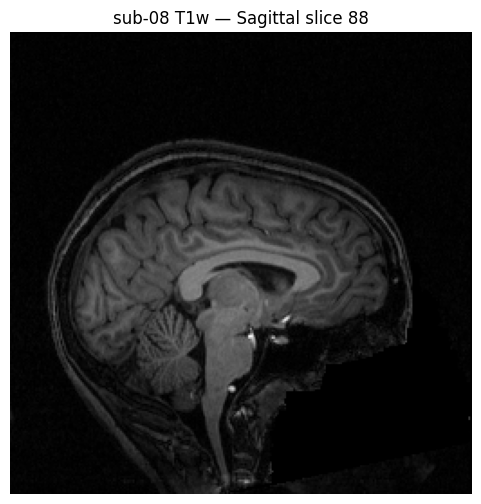

In [8]:
import nibabel as nib
import matplotlib.pyplot as plt

# Load the T1w NIfTI image
img = nib.load('ds000102/sub-08/anat/sub-08_T1w.nii.gz')

# Inspect basic properties
print(f"Image shape: {img.shape}")
print(f"Voxel size (mm): {img.header.get_zooms()}")
print(f"Data type: {img.get_data_dtype()}")

# Display a sagittal slice
data = img.get_fdata()
mid_sagittal = data.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(data[mid_sagittal, :, :].T, cmap='gray', origin='lower')
plt.title(f'sub-08 T1w — Sagittal slice {mid_sagittal}')
plt.axis('off')
plt.show()

### Troubleshooting: Jupyter Notebook

:::{tip}
**`ModuleNotFoundError: No module named 'module'`** — You are likely running this notebook outside of the Neurodesk environment. The `module` package is pre-installed in Neurodesk's Jupyter kernel.

**`SyntaxError` on `await`** — Make sure you are using a Jupyter notebook (`.ipynb`) — `await` at the top level is supported by IPython's built-in event loop. It won't work in a plain `.py` script without `asyncio`.

**Tool command not found after `module.load()`** — The module sets environment variables in the notebook's kernel process. If using `!` shell commands, they inherit this environment. If spawning subprocesses differently, you may need to pass the environment explicitly via `env=os.environ`.
:::

## 3. Neurodesktop Terminal — Loading ANTs

The Neurodesktop provides a full graphical Linux desktop environment that you can access directly from JupyterLab. To open it, click the **Neurodesktop** button in the JupyterLab Launcher (under "Notebook").

![The JupyterLab Launcher with the Neurodesktop button highlighted](/static/tutorials/about_neurodesk/launcher_neurodesktop.png)
*Click "Neurodesktop" in the JupyterLab Launcher to open the desktop environment in a new tab.*

Once open, a window will open. You'll see a Linux desktop with a taskbar, file manager, and application menu.

![The Neurodesktop desktop environment](/static/tutorials/about_neurodesk/neurodesktop_interface.png)
*The Neurodesktop environment — a full Linux desktop with taskbar, file manager, and application menu.*

In this section, we'll load **ANTs** from the Neurodesktop's LXTerminal to demonstrate that the same module system works across all interfaces.

### Opening a terminal in Neurodesktop

From the Neurodesktop, open **LXTerminal** from the taskbar at the bottom of the screen.

![Neurodesktop with LXTerminal open](/static/tutorials/about_neurodesk/desktop_terminal.png)
*The Neurodesktop environment with LXTerminal open from the taskbar.*

### Loading ANTs with `ml`

The `ml` command works identically in the Neurodesktop terminal:

```bash
# Load ANTs
ml ants/2.5.3

# Verify it's loaded
ml list

# Check that ANTs tools are accessible
which antsRegistration
antsRegistration --version
```

This is the same module system as the Jupyter Terminal — the only difference is that here you also have access to a full graphical display, so you can launch GUI tools alongside your command-line work.

### Launching GUI tools from the terminal

One advantage of the Neurodesktop terminal is that you can launch graphical tools directly:

```bash
# Load FSL and launch FSLeyes
ml fsl/6.0.7.8
fsleyes &
```

:::{note}
The `&` at the end runs the GUI application in the background so you can continue using the terminal.
:::

![FSLeyes running inside the Neurodesktop environment](/static/tutorials/about_neurodesk/desktop_fsleyes.png)
*FSLeyes launched from the Neurodesktop terminal, displaying a brain image.*

## 4. Neurodesktop Application Menu

The Neurodesktop includes an **application menu** that lets you launch tools with a single click — no terminal commands required. This is the easiest method for users who prefer a point-and-click workflow.

### Using the application menu

![Neurodesktop application menu with tool categories](/static/tutorials/about_neurodesk/desktop_app_menu.png)
*The Applications menu showing Neurodesk tool categories on the desktop.*

**Step-by-step:**

1. Click the **Applications** menu in the desktop taskbar
2. Navigate to **Neurodesk**
3. Browse categories (e.g., *All Applications*, *Structural Imaging*, *Functional Imaging*)
4. Click on the desired tool (e.g., *FSLeyes 6.0.7.14*)
5. Wait briefly while the container initialises (first launch may take a moment)
6. The application opens — ready to use!

The application menu automatically handles the `ml load` step behind the scenes. GUI tools open in their own window; CLI tools open in a pre-configured terminal.

### Troubleshooting: Application Menu

:::{tip}
**Application doesn't appear in the menu** — The application menu is populated from the available containers. If a tool is missing, it may not be installed in your Neurodesk image. Check `ml avail` in a terminal. You can also request new tools or check available containers at the [Neurocontainers UI](https://neurodesk.org/neurocontainers-ui/).

**GUI application window is blank or unresponsive** — This can happen on slow networks. Try refreshing your browser tab or closing and reopening the Neurodesktop tab from the Launcher.
:::

## 5. Putting It All Together

Throughout this tutorial, we loaded different tools through different methods:

- **FSL** via the Jupyter Terminal (`ml fsl/6.0.7.8`)
- **FreeSurfer** via the Jupyter Notebook (`await module.load('freesurfer/7.4.1')`)
- **ANTs** via the Neurodesktop Terminal (`ml ants/2.5.3`)
- **FSLeyes** via the Neurodesktop Application Menu (point-and-click)

All methods use the same underlying module system. In a notebook, we can load all three together and verify they are available side by side:

In [9]:
import module

await module.purge()

# Load all three tools — each originally demonstrated via a different method
await module.load('fsl/6.0.7.8')        # Method 1: Jupyter Terminal
await module.load('freesurfer/7.4.1')    # Method 2: Jupyter Notebook
await module.load('ants/2.5.3')          # Method 3: Neurodesktop Terminal

await module.list()

['fsl/6.0.7.8', 'freesurfer/7.4.1', 'ants/2.5.3']

In [10]:
# Verify all three tools are accessible
import subprocess, os

tools = {
    'FSL': ['cat', os.path.join(os.environ.get('FSLDIR', ''), 'etc', 'fslversion')],
    'FreeSurfer': ['recon-all', '--version'],
    'ANTs': ['antsRegistration', '--version'],
}

for name, cmd in tools.items():
    result = subprocess.run(cmd, capture_output=True, text=True, env=os.environ)
    version = (result.stdout.strip() or result.stderr.strip()).splitlines()[0]
    print(f"{name}: {version}")

FSL: 6.0.7.8
FreeSurfer: freesurfer-linux-centos8_x86_64-7.4.1-20230613-7eb8460
ANTs: /cvmfs/neurodesk.ardc.edu.au/containers/ants_2.5.3_20240925/antsRegistration: line 3: 71026 Illegal instruction     singularity --silent exec --cleanenv --env DISPLAY=$DISPLAY $neurodesk_singularity_opts --pwd "$PWD" /cvmfs/neurodesk.ardc.edu.au/containers/ants_2.5.3_20240925/ants_2.5.3_20240925.simg antsRegistration "$@"


Regardless of whether you load tools from a Jupyter terminal, a notebook cell, or the Neurodesktop — they all share the same environment. You can mix and match access methods within a single session.

:::{admonition} Which method should I use?
:class: dropdown tip

**I want to run a quick command**
: Use the **Jupyter Terminal** — open one from the Launcher and type `ml <tool>`.

**I'm building an analysis pipeline**
: Use the **Jupyter Notebook** — `await module.load()` keeps your setup documented alongside your code.

**I need to visualise data with a GUI tool**
: Use the **Neurodesktop Terminal** or **Application Menu** — both give you access to graphical applications.

**I'm new to the command line**
: Use the **Sidebar Panel** or **Application Menu** — point-and-click, no commands needed.
:::

## 6. Comparison and Quick Reference

| Feature | Sidebar Panel | Jupyter Terminal | Jupyter Notebook | Neurodesktop Terminal | Neurodesktop App Menu |
|---|---|---|---|---|---|
| **Interface** | Point-and-click | Command line | Python cells | Command line (GUI display) | Point-and-click |
| **Load command** | Click "Load" | `ml <tool>` | `await module.load('<tool>')` | `ml <tool>` | Automatic |
| **List available** | Browse + search | `ml avail` | `!ml avail` | `ml avail` | Browse categories |
| **List loaded** | "Loaded Modules" panel | `ml list` | `await module.list()` | `ml list` | — |
| **Unload** | Click "Unload" | `ml -<tool>` | — | `ml -<tool>` | — |
| **Purge all** | — | `ml purge` | `await module.purge()` | `ml purge` | — |
| **Search** | Filter box | `ml spider <keyword>` | `!ml spider <keyword>` | `ml spider <keyword>` | — |
| **GUI tools** | No display | No display | No display | Full support | Full support |
| **Reproducibility** | Manual | Script it yourself | Excellent (code + docs) | Script it yourself | Manual |
| **Best for** | Quick discovery + load | Quick tasks, scripting | Analysis pipelines, teaching | Visualisation + CLI | Users new to CLI |
| **Terminal caveat** | Must open new terminal | — | — | — | — |

## Dependencies in Jupyter/Python

Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook.

In [11]:
%load_ext watermark

%watermark
%watermark --iversions

Last updated: 2026-03-12T22:21:37.268411+00:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.7.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.10.14-linuxkit
Machine     : aarch64
Processor   : aarch64
CPU cores   : 8
Architecture: 64bit

matplotlib: 3.10.8
nibabel   : 5.3.3

